# Q4 Local UdonPred Ensembles

Question: can ensembles of UdonPred's seven dataset-specific heads outperform individual heads, and can one ensemble generalize across all seven test sets?

This notebook uses only local UdonPred predictions. External CAID methods are context for why ensembling is interesting, but they are not used as inputs here. Learned weights and stacking models are fit on validation predictions, then evaluated on held-out test predictions.

## 1. Setup

In [6]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from torchmetrics.functional import auroc, average_precision, spearman_corrcoef

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

UDONPRED_DIR = ROOT / "UdonPred"
RESULTS = ROOT / "results"
TEST_PREDICTION_ROOT = RESULTS / "udonpred_matrix" / "predictions"
VALID_PREDICTION_ROOT = RESULTS / "udonpred_validation_matrix" / "predictions"
ENSEMBLE_DIR = RESULTS / "ensembles"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]
NEGATED_DATASETS = {"chezod", "plddt"}
MASK_VALUE = 999.0
METRIC_COLS = [
    "trizod",
    "chezod",
    "softdis",
    "pdbflex",
    "atlas",
    "plddt",
    "disprot\n(AP)",
    "disprot\n(AUROC)",
]

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

## 2. Shared Helpers

The helpers below mirror the earlier notebooks: CheZOD and pLDDT are oriented so larger values mean more disorder, masked labels are excluded, continuous targets use Spearman correlation, and DisProt uses AP/AUROC.

In [7]:
def read_jsonl_records(path: Path) -> dict[str, dict[str, object]]:
    records = {}
    with path.open() as handle:
        for line in handle:
            raw = json.loads(line)
            records[str(raw["id"])] = {
                "sequence": str(raw["x_0"]),
                "labels": np.asarray(raw["y"], dtype=np.float64),
            }
    return records


def normalize_prediction_id(protein_id: str) -> str:
    protein_id = protein_id.strip().lstrip(">")
    if len(protein_id) >= 6 and protein_id.isdigit():
        base_len = len(protein_id) - 3
        return protein_id[:base_len] + "_" + "_".join(protein_id[base_len:])
    return protein_id


def read_caid_dir(input_dir: Path) -> dict[str, np.ndarray]:
    predictions = {}
    for path in sorted(input_dir.glob("*.caid")):
        with path.open() as handle:
            lines = handle.readlines()
        if not lines:
            raise ValueError(f"Empty prediction file: {path}")
        protein_id = normalize_prediction_id(lines[0])
        scores = []
        for line in lines[1:]:
            line = line.strip()
            if line:
                scores.append(float(line.split("\t")[2]))
        predictions[protein_id] = np.asarray(scores, dtype=np.float64)
    return predictions


def count_fasta_records(path: Path) -> int:
    return sum(1 for line in path.read_text().splitlines() if line.startswith(">"))


def prediction_dir_complete(result_dir: Path, fasta_path: Path) -> bool:
    return result_dir.exists() and len(list(result_dir.glob("*.caid"))) == count_fasta_records(fasta_path)


def labels_in_disorder_direction(labels: np.ndarray, dataset: str) -> np.ndarray:
    return -labels if dataset in NEGATED_DATASETS else labels


def preds_in_disorder_direction(preds: np.ndarray, train_dataset: str) -> np.ndarray:
    return -preds if train_dataset in NEGATED_DATASETS else preds


def metric_columns_for_dataset(dataset: str) -> list[str]:
    if dataset == "disprot":
        return ["disprot\n(AP)", "disprot\n(AUROC)"]
    return [dataset]


def evaluate_vector(labels: np.ndarray, preds: np.ndarray, dataset: str) -> dict[str, float]:
    if len(labels) == 0:
        return {column: math.nan for column in metric_columns_for_dataset(dataset)}
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
    preds_tensor = torch.tensor(preds, dtype=torch.float32)
    if dataset == "disprot":
        binary_labels = labels_tensor.to(torch.int)
        return {
            "disprot\n(AP)": float(average_precision(preds_tensor, binary_labels, task="binary")),
            "disprot\n(AUROC)": float(auroc(preds_tensor, binary_labels, task="binary")),
        }
    if np.unique(labels).size < 2 or np.unique(preds).size < 2:
        return {dataset: math.nan}
    return {dataset: float(spearman_corrcoef(preds_tensor, labels_tensor))}


def primary_metric(dataset: str) -> str:
    return "disprot\n(AP)" if dataset == "disprot" else dataset


def load_aligned_stack(split: str, prediction_root: Path, target_dataset: str) -> dict[str, object]:
    records = read_jsonl_records(UDONPRED_DIR / "data" / target_dataset / f"{split}.jsonl")
    pred_maps = {
        train_dataset: read_caid_dir(prediction_root / f"{train_dataset}_{target_dataset}")
        for train_dataset in DATASETS
    }

    label_chunks = []
    pred_chunks_by_train = {train_dataset: [] for train_dataset in DATASETS}
    residue_count = 0
    for protein_id, record in records.items():
        labels = np.asarray(record["labels"], dtype=np.float64)
        mask = np.isfinite(labels) & (labels != MASK_VALUE)
        if not np.any(mask):
            continue

        for train_dataset, pred_map in pred_maps.items():
            if protein_id not in pred_map:
                raise ValueError(f"Missing prediction for {protein_id} in {train_dataset}_{target_dataset}")
            preds = pred_map[protein_id]
            if len(preds) != len(labels):
                raise ValueError(
                    f"{train_dataset}_{target_dataset}/{protein_id}: prediction length {len(preds)} "
                    f"!= label length {len(labels)}"
                )
            pred_chunks_by_train[train_dataset].append(preds_in_disorder_direction(preds, train_dataset)[mask])

        label_chunks.append(labels_in_disorder_direction(labels, target_dataset)[mask])
        residue_count += int(mask.sum())

    y = np.concatenate(label_chunks)
    x = np.column_stack([np.concatenate(pred_chunks_by_train[train_dataset]) for train_dataset in DATASETS])
    return {"dataset": target_dataset, "split": split, "X": x, "y": y, "n_residues": residue_count}


def load_split_stacks(split: str, prediction_root: Path) -> dict[str, dict[str, object]]:
    return {
        target_dataset: load_aligned_stack(split, prediction_root, target_dataset)
        for target_dataset in DATASETS
    }

## 3. Generate Missing Validation Predictions

Learned ensembles must be fit on validation labels, not test labels. This cell creates the validation prediction matrix if it is missing. It skips complete prediction directories.

In [8]:
RUN_VALIDATION_PREDICTIONS = True

missing_validation_jobs = []
for train_dataset in DATASETS:
    for target_dataset in DATASETS:
        fasta_path = UDONPRED_DIR / "data" / target_dataset / "valid.fasta"
        result_dir = VALID_PREDICTION_ROOT / f"{train_dataset}_{target_dataset}"
        if not prediction_dir_complete(result_dir, fasta_path):
            missing_validation_jobs.append((train_dataset, target_dataset, fasta_path, result_dir))

print(f"Missing validation prediction jobs: {len(missing_validation_jobs)}")

if RUN_VALIDATION_PREDICTIONS:
    for train_dataset, target_dataset, fasta_path, result_dir in missing_validation_jobs:
        result_dir.mkdir(parents=True, exist_ok=True)
        cmd = [
            sys.executable,
            "predict.py",
            str(fasta_path),
            str(UDONPRED_DIR / "weights"),
            "--target",
            train_dataset,
            "--output",
            str(result_dir),
            "--device",
            "cuda",
            "--batch-size",
            "2000",
            "--smooth",
            "1.5",
        ]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, cwd=UDONPRED_DIR, check=True)
else:
    print("Set RUN_VALIDATION_PREDICTIONS = True to generate missing validation predictions.")

Missing validation prediction jobs: 0


## 4. Load And Sanity-Check Aligned Predictions

In [9]:
test_stacks = load_split_stacks("test", TEST_PREDICTION_ROOT)
valid_stacks = load_split_stacks("valid", VALID_PREDICTION_ROOT)

alignment_summary = pd.DataFrame(
    [
        {"split": "test", "dataset": dataset, "n_residues": stack["n_residues"], "n_heads": stack["X"].shape[1]}
        for dataset, stack in test_stacks.items()
    ]
    + [
        {"split": "valid", "dataset": dataset, "n_residues": stack["n_residues"], "n_heads": stack["X"].shape[1]}
        for dataset, stack in valid_stacks.items()
    ]
)
display(alignment_summary)

,split,dataset,n_residues,n_heads
0,test,trizod,37133,7
1,test,chezod,13068,7
2,test,softdis,271668,7
3,test,pdbflex,225651,7
4,test,atlas,16907,7
5,test,plddt,62945,7
6,test,disprot,99239,7
7,valid,trizod,77160,7
8,valid,chezod,13334,7
9,valid,softdis,424887,7


In [10]:
def score_individual_heads(stacks: dict[str, dict[str, object]]) -> pd.DataFrame:
    rows = []
    for train_index, train_dataset in enumerate(DATASETS):
        row = {"train_dataset": train_dataset}
        for target_dataset, stack in stacks.items():
            row.update(evaluate_vector(stack["y"], stack["X"][:, train_index], target_dataset))
        rows.append(row)
    return pd.DataFrame(rows).set_index("train_dataset")[METRIC_COLS]


recomputed_individual = score_individual_heads(test_stacks)
published_individual = pd.read_csv(RESULTS / "udonpred_matrix" / "matrix.csv").set_index("train_dataset")[METRIC_COLS]
published_individual = published_individual.apply(pd.to_numeric)

max_abs_delta = (recomputed_individual - published_individual).abs().max().max()
print(f"Max absolute delta versus results/udonpred_matrix/matrix.csv: {max_abs_delta:.6f}")
if max_abs_delta > 5e-4:
    raise ValueError("Recomputed individual-head matrix does not match the saved UdonPred matrix.")

best_individual_scores = recomputed_individual.max(axis=0)
best_individual_heads = recomputed_individual.idxmax(axis=0)
display(recomputed_individual.style.format("{:.3f}"))

Max absolute delta versus results/udonpred_matrix/matrix.csv: 0.000016


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
train_dataset,,,,,,,,
trizod,0.508,0.708,0.257,-0.006,0.413,0.719,0.899,0.930
chezod,0.486,0.691,0.235,-0.039,0.327,0.713,0.890,0.925
softdis,0.470,0.537,0.500,0.150,0.597,0.784,0.872,0.918
pdbflex,0.287,0.286,0.292,0.395,0.349,0.520,0.519,0.737
atlas,0.400,0.595,0.310,0.056,0.708,0.719,0.870,0.920
plddt,0.423,0.625,0.284,0.104,0.512,0.839,0.875,0.927
disprot,0.364,0.663,0.255,0.099,0.624,0.774,0.935,0.959


## 5. Fit Non-Leaky Ensembles On Validation Data

In [11]:
def concatenate_stacks(stacks: list[dict[str, object]]) -> tuple[np.ndarray, np.ndarray]:
    x = np.vstack([stack["X"] for stack in stacks])
    y = np.concatenate([stack["y"] for stack in stacks])
    return x, y


def fit_convex_weights(stacks: list[dict[str, object]]) -> np.ndarray:
    x, y = concatenate_stacks(stacks)
    n_heads = x.shape[1]
    start = np.full(n_heads, 1.0 / n_heads)
    constraints = ({"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},)
    bounds = [(0.0, 1.0)] * n_heads

    def objective(weights: np.ndarray) -> float:
        residual = x @ weights - y
        return float(np.mean(residual * residual))

    result = minimize(objective, start, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(f"Convex-weight optimization failed: {result.message}")
    weights = np.asarray(result.x, dtype=np.float64)
    weights[weights < 1e-10] = 0.0
    return weights / weights.sum()


def fit_ridge_model(stacks: list[dict[str, object]], alpha: float = 1.0) -> Ridge:
    x, y = concatenate_stacks(stacks)
    model = Ridge(alpha=alpha)
    model.fit(x, y)
    return model


valid_individual = score_individual_heads(valid_stacks)
selected_head_by_target = {
    dataset: valid_individual[primary_metric(dataset)].idxmax()
    for dataset in DATASETS
}

global_convex_weights = fit_convex_weights([valid_stacks[dataset] for dataset in DATASETS])
per_target_convex_weights = {
    dataset: fit_convex_weights([valid_stacks[dataset]])
    for dataset in DATASETS
}

global_ridge = fit_ridge_model([valid_stacks[dataset] for dataset in DATASETS])
per_target_ridge = {
    dataset: fit_ridge_model([valid_stacks[dataset]])
    for dataset in DATASETS
}

weight_rows = [
    {"strategy": "global_convex_validation", "target_dataset": "all", **dict(zip(DATASETS, global_convex_weights))}
]
weight_rows += [
    {"strategy": "per_target_convex_validation", "target_dataset": dataset, **dict(zip(DATASETS, weights))}
    for dataset, weights in per_target_convex_weights.items()
]
weights_df = pd.DataFrame(weight_rows)
weights_df.to_csv(ENSEMBLE_DIR / "ensemble_weights.csv", index=False)

print("Validation-selected head by target:")
display(pd.Series(selected_head_by_target, name="selected_train_dataset").to_frame())
display(weights_df.style.format({dataset: "{:.3f}" for dataset in DATASETS}))

Validation-selected head by target:


,selected_train_dataset
trizod,trizod
chezod,chezod
softdis,softdis
pdbflex,pdbflex
atlas,atlas
plddt,plddt
disprot,disprot


,strategy,target_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot
0,global_convex_validation,all,0.914,0.000,0.000,0.000,0.000,0.086,0.000
1,per_target_convex_validation,trizod,0.944,0.000,0.023,0.000,0.003,0.000,0.030
2,per_target_convex_validation,chezod,0.000,1.000,0.000,0.000,0.000,0.000,0.000
3,per_target_convex_validation,softdis,0.000,0.000,1.000,0.000,0.000,0.000,0.000
4,per_target_convex_validation,pdbflex,0.000,0.000,0.000,1.000,0.000,0.000,0.000
5,per_target_convex_validation,atlas,0.000,0.000,0.000,0.000,1.000,0.000,0.000
6,per_target_convex_validation,plddt,0.000,0.000,0.000,0.000,0.000,1.000,0.000
7,per_target_convex_validation,disprot,0.000,0.001,0.000,0.000,0.000,0.000,0.999


## 6. Evaluate Ensemble Strategies On Test Sets

In [12]:
def strategy_predictions_for_dataset(strategy: str, dataset: str, stack: dict[str, object]) -> np.ndarray:
    x = stack["X"]
    if strategy == "simple_mean_all_heads":
        return x.mean(axis=1)
    if strategy == "validation_selected_single_head":
        return x[:, DATASETS.index(selected_head_by_target[dataset])]
    if strategy == "global_convex_validation":
        return x @ global_convex_weights
    if strategy == "per_target_convex_validation":
        return x @ per_target_convex_weights[dataset]
    if strategy == "global_ridge_stacking_validation":
        return global_ridge.predict(x)
    if strategy == "per_target_ridge_stacking_validation":
        return per_target_ridge[dataset].predict(x)
    raise ValueError(f"Unknown strategy: {strategy}")


strategies = [
    "best_individual_test_oracle",
    "simple_mean_all_heads",
    "validation_selected_single_head",
    "global_convex_validation",
    "per_target_convex_validation",
    "global_ridge_stacking_validation",
    "per_target_ridge_stacking_validation",
]

rows = []
for strategy in strategies:
    row = {"strategy": strategy}
    if strategy == "best_individual_test_oracle":
        row.update(best_individual_scores.to_dict())
    else:
        for dataset, stack in test_stacks.items():
            preds = strategy_predictions_for_dataset(strategy, dataset, stack)
            row.update(evaluate_vector(stack["y"], preds, dataset))
    rows.append(row)

ensemble_matrix = pd.DataFrame(rows).set_index("strategy")[METRIC_COLS]
ensemble_delta = ensemble_matrix.subtract(best_individual_scores, axis="columns")

summary_rows = []
for strategy in ensemble_matrix.index:
    deltas = ensemble_delta.loc[strategy]
    summary_rows.append(
        {
            "strategy": strategy,
            "mean_score": float(ensemble_matrix.loc[strategy].mean()),
            "mean_delta_vs_best_individual": float(deltas.mean()),
            "wins_vs_best_individual": int((deltas > 1e-6).sum()),
            "ties_vs_best_individual": int((deltas.abs() <= 1e-6).sum()),
            "losses_vs_best_individual": int((deltas < -1e-6).sum()),
            "best_delta": float(deltas.max()),
            "worst_delta": float(deltas.min()),
        }
    )
ensemble_summary = pd.DataFrame(summary_rows).set_index("strategy")

ensemble_matrix.to_csv(ENSEMBLE_DIR / "ensemble_matrix.csv")
ensemble_delta.to_csv(ENSEMBLE_DIR / "ensemble_delta_vs_best_individual.csv")
ensemble_summary.to_csv(ENSEMBLE_DIR / "ensemble_summary.csv")
valid_individual.to_csv(ENSEMBLE_DIR / "validation_individual_matrix.csv")

display(ensemble_matrix.style.format("{:.3f}"))
display(ensemble_delta.style.format("{:+.3f}"))
display(ensemble_summary.style.format("{:.3f}"))

,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,,
best_individual_test_oracle,0.508,0.708,0.500,0.395,0.708,0.839,0.935,0.959
simple_mean_all_heads,0.454,0.650,0.306,0.102,0.530,0.837,0.893,0.937
validation_selected_single_head,0.508,0.691,0.500,0.395,0.708,0.839,0.935,0.959
global_convex_validation,0.434,0.643,0.288,0.103,0.521,0.839,0.888,0.934
per_target_convex_validation,0.508,0.691,0.500,0.395,0.708,0.839,0.936,0.959
global_ridge_stacking_validation,-0.421,-0.653,-0.147,-0.123,-0.276,-0.594,0.191,0.126
per_target_ridge_stacking_validation,0.502,0.702,0.508,0.434,0.660,0.847,0.932,0.954


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,,
best_individual_test_oracle,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
simple_mean_all_heads,-0.054,-0.058,-0.194,-0.293,-0.178,-0.002,-0.042,-0.022
validation_selected_single_head,+0.000,-0.017,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
global_convex_validation,-0.073,-0.065,-0.212,-0.292,-0.187,-0.000,-0.047,-0.025
per_target_convex_validation,+0.001,-0.017,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
global_ridge_stacking_validation,-0.929,-1.360,-0.647,-0.518,-0.984,-1.433,-0.744,-0.833
per_target_ridge_stacking_validation,-0.006,-0.006,+0.008,+0.039,-0.048,+0.008,-0.003,-0.005


,mean_score,mean_delta_vs_best_individual,wins_vs_best_individual,ties_vs_best_individual,losses_vs_best_individual,best_delta,worst_delta
strategy,,,,,,,
best_individual_test_oracle,0.694,0.000,0.000,8.000,0.000,0.000,0.000
simple_mean_all_heads,0.589,-0.105,0.000,0.000,8.000,-0.002,-0.293
validation_selected_single_head,0.692,-0.002,0.000,7.000,1.000,0.000,-0.017
global_convex_validation,0.581,-0.113,0.000,0.000,8.000,-0.000,-0.292
per_target_convex_validation,0.692,-0.002,3.000,4.000,1.000,0.001,-0.017
global_ridge_stacking_validation,-0.237,-0.931,0.000,0.000,8.000,-0.518,-1.433
per_target_ridge_stacking_validation,0.692,-0.002,3.000,0.000,5.000,0.039,-0.048


## 7. Plots

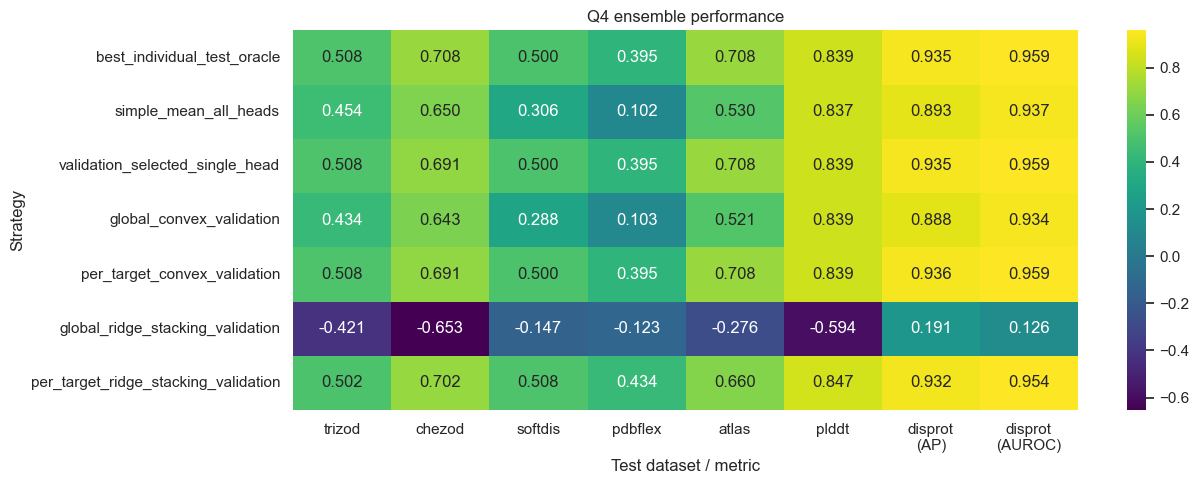

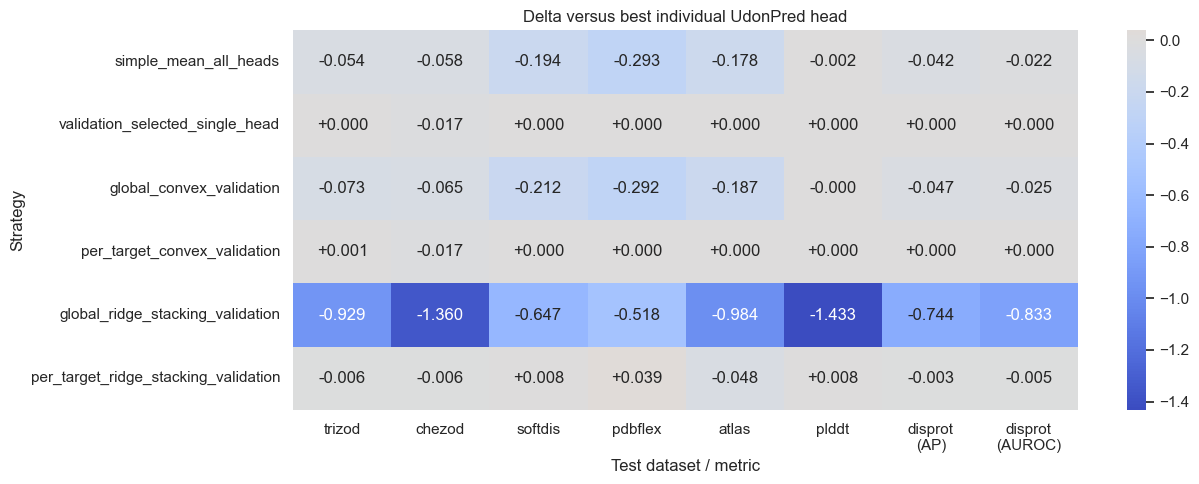

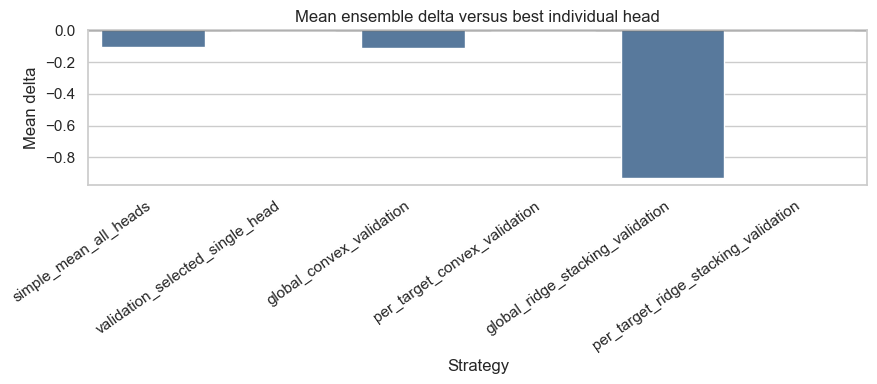

In [13]:
plt.figure(figsize=(13, 5))
sns.heatmap(ensemble_matrix, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Test dataset / metric")
plt.ylabel("Strategy")
plt.title("Q4 ensemble performance")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ensemble_matrix_heatmap.png", dpi=200)
plt.show()

plot_delta = ensemble_delta.drop(index="best_individual_test_oracle")
plt.figure(figsize=(13, 5))
sns.heatmap(plot_delta, annot=True, fmt="+.3f", cmap="coolwarm", center=0)
plt.xlabel("Test dataset / metric")
plt.ylabel("Strategy")
plt.title("Delta versus best individual UdonPred head")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ensemble_delta_vs_best_individual_heatmap.png", dpi=200)
plt.show()

summary_plot = ensemble_summary.drop(index="best_individual_test_oracle").reset_index()
plt.figure(figsize=(9, 4))
sns.barplot(data=summary_plot, x="strategy", y="mean_delta_vs_best_individual", color="#4C78A8")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.xlabel("Strategy")
plt.ylabel("Mean delta")
plt.title("Mean ensemble delta versus best individual head")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ensemble_mean_delta_barplot.png", dpi=200)
plt.show()

## 8. Interpretation Draft

In [14]:
non_oracle = ensemble_matrix.drop(index="best_individual_test_oracle")
best_strategy_by_metric = non_oracle.idxmax(axis=0)
best_score_by_metric = non_oracle.max(axis=0)

print("Q4 report notes:")
print("- Best individual heads by test metric are an optimistic oracle comparison because the head is selected using test performance.")
print("- Simple mean, validation-selected head, global convex, and global ridge are non-leaky when validation predictions are used for selection/fitting.")
print("- Per-target convex and per-target ridge are non-leaky, but they are dataset-specific upper comparisons rather than a single general ensemble.")
print()
print("Best non-oracle ensemble per metric:")
for metric in METRIC_COLS:
    print(f"- {metric}: {best_strategy_by_metric[metric]} ({best_score_by_metric[metric]:.3f}); "
          f"best individual {best_individual_scores[metric]:.3f} from {best_individual_heads[metric]}")

global_rows = ["global_convex_validation", "global_ridge_stacking_validation"]
print()
print("Single global ensemble generalization:")
for row in global_rows:
    stats = ensemble_summary.loc[row]
    print(
        f"- {row}: mean delta {stats['mean_delta_vs_best_individual']:.3f}, "
        f"wins {int(stats['wins_vs_best_individual'])}/{len(METRIC_COLS)}, "
        f"worst delta {stats['worst_delta']:.3f}."
    )

Q4 report notes:
- Best individual heads by test metric are an optimistic oracle comparison because the head is selected using test performance.
- Simple mean, validation-selected head, global convex, and global ridge are non-leaky when validation predictions are used for selection/fitting.
- Per-target convex and per-target ridge are non-leaky, but they are dataset-specific upper comparisons rather than a single general ensemble.

Best non-oracle ensemble per metric:
- trizod: per_target_convex_validation (0.508); best individual 0.508 from trizod
- chezod: per_target_ridge_stacking_validation (0.702); best individual 0.708 from trizod
- softdis: per_target_ridge_stacking_validation (0.508); best individual 0.500 from softdis
- pdbflex: per_target_ridge_stacking_validation (0.434); best individual 0.395 from pdbflex
- atlas: validation_selected_single_head (0.708); best individual 0.708 from atlas
- plddt: per_target_ridge_stacking_validation (0.847); best individual 0.839 from plddt
